# SEGB Report Demo (Prototype)

This notebook generates a **single simulation** and then runs SPARQL reports that are already feasible with the current SEGB logging model.

Implemented report examples in this notebook:
- Participants in the log
- ML models used (including synthetic dataset/evaluation links for demo)
- Temporal emotion analysis
- Extreme emotion report
- Movement/displacement report from robot states


In [1]:
# Ensure repository root is on sys.path when notebook runs from any folder
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'examples').exists() and (candidate / 'segb_logger').exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Repository root not found. Open notebook inside the SEGB repo.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Using repo root: {repo_root}')


Using repo root: /home/canarionjl/Escritorio/phd/AMOR/segb


In [2]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from rdflib import Literal
from rdflib.namespace import RDF, RDFS, XSD

from examples.run_simulation import ARI_NAMESPACE, TIAGO_NAMESPACE, run_simulation
from segb_logger import ActivityKind, EmotionScore, RobotStateSnapshot, SemanticSEGBLogger
from segb_logger.namespaces import EMOML, MLS, OA, ONYX, ORO, PROV, SCHEMA, SEGB

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


In [3]:
# 1) Base simulation (already in the repository)
result = run_simulation()
graph = result.graph

print('Base simulation generated')
print(' - SharedEvent URI:', result.shared_event_uri)
print(' - Initial triples:', len(graph))


Base simulation generated
 - SharedEvent URI: https://gsi.upm.es/segb/shared-events/human_utterance_3be7c5eded6c32c28834
 - Initial triples: 75


In [4]:
# 2) Enrich with extra data needed by reports (without changing library code)
ari_logger = SemanticSEGBLogger(
    base_namespace=ARI_NAMESPACE,
    robot_id='ari1',
    robot_name='ARI',
    graph=graph,
)
tiago_logger = SemanticSEGBLogger(
    base_namespace=TIAGO_NAMESPACE,
    robot_id='tiago1',
    robot_name='TIAGo',
    graph=graph,
)

human_uri = result.human_uri

# ML models
asr_model = ari_logger.register_ml_model('asr_vosk_es', label='ASR Vosk ES', version='0.3')
emotion_model = ari_logger.register_ml_model('emotion_big6_v1', label='Emotion Big6 CNN', version='1.0')
vision_model = ari_logger.register_ml_model('vision_human_detector_v1', label='Human Detector', version='2.1')

# Link ASR model to the existing listening activity from the simulation
ari_listening_activity = ari_logger.resolve_term(f'{ARI_NAMESPACE}activity/ari_listening_1')
graph.add((ari_listening_activity, SEGB.usedMLModel, asr_model))

# Add one vision activity to show filtering by use-case
vision_activity = ari_logger.log_activity(
    activity_id='vision_perception_1',
    activity_kind=ActivityKind.HUMAN_DETECTION,
    started_at=datetime.now(timezone.utc),
    ended_at=datetime.now(timezone.utc),
    used_models=[vision_model],
    related_shared_events=[result.shared_event_uri],
)

# Synthetic training run + dataset + evaluation (report demo data)
dataset_uri = ari_logger.resource_uri('dataset', 'emotion_dataset_v1')
graph.add((dataset_uri, RDF.type, MLS.Dataset))
graph.add((dataset_uri, RDFS.label, Literal('EmotionDataset v1')))

eval_uri = ari_logger.resource_uri('model-eval', 'emotion_accuracy_eval_1')
graph.add((eval_uri, RDF.type, MLS.ModelEvaluation))
graph.add((eval_uri, MLS.hasValue, Literal(0.89, datatype=XSD.double)))

train_run = ari_logger.log_activity(
    activity_id='emotion_model_training_run_1',
    activity_kind=ActivityKind.ML_RUN,
    started_at=datetime.now(timezone.utc) - timedelta(minutes=30),
    ended_at=datetime.now(timezone.utc) - timedelta(minutes=20),
    used_models=[emotion_model],
    produced_entity_results=[emotion_model, eval_uri],
)
graph.add((train_run, MLS.hasInput, dataset_uri))
graph.add((train_run, MLS.hasOutput, emotion_model))
graph.add((train_run, MLS.hasOutput, eval_uri))

# Emotion timeline for Maria: one emotion per instant with a coherent scenario.
# Scenario:
# - Maria asks for climate news.
# - ARI provides a worrying climate summary.
# - ARI then offers a concrete support plan.
base_t = datetime.now(timezone.utc) - timedelta(minutes=10)

news_summary_activity = ari_logger.log_activity(
    activity_id='ari_news_summary_1',
    activity_kind=ActivityKind.RESPONSE,
    started_at=base_t,
    ended_at=base_t + timedelta(seconds=5),
    triggered_by_activity=ari_listening_activity,
    triggered_by_entity=result.ari_observation_uri,
    related_shared_events=[result.shared_event_uri],
    used_entities=[result.ari_observation_uri],
)
news_summary_message = ari_logger.log_message(
    'Climate update: heat waves are increasing and local air quality worsened this week.',
    message_id='ari_news_summary_msg_1',
    generated_by_activity=news_summary_activity,
    message_types=['oro:ResponseMessage'],
    previous_message=result.ari_response_uri,
)

support_activity = ari_logger.log_activity(
    activity_id='ari_support_plan_1',
    activity_kind=ActivityKind.RESPONSE,
    started_at=base_t + timedelta(minutes=6),
    ended_at=base_t + timedelta(minutes=6, seconds=5),
    triggered_by_activity=news_summary_activity,
    triggered_by_entity=news_summary_message,
    used_entities=[news_summary_message],
)
support_message = ari_logger.log_message(
    'I can show you practical protection tips and schedule reminders for tomorrow.',
    message_id='ari_support_plan_msg_1',
    generated_by_activity=support_activity,
    message_types=['oro:ResponseMessage'],
    previous_message=news_summary_message,
)

emotion_timeline = [
    {
        'category': EMOML.big6_surprise,
        'intensity': 0.42,
        'confidence': 0.91,
        'trigger_entity': result.ari_observation_uri,
        'note': 'Maria notices both robots detected her request quickly.',
    },
    {
        'category': EMOML.big6_fear,
        'intensity': 0.86,
        'confidence': 0.93,
        'trigger_entity': news_summary_message,
        'note': 'Maria reacts with fear after hearing about stronger heat waves.',
    },
    {
        'category': EMOML.big6_sadness,
        'intensity': 0.79,
        'confidence': 0.92,
        'trigger_entity': news_summary_message,
        'note': 'Maria feels sadness when impacts on vulnerable people are mentioned.',
    },
    {
        'category': EMOML.big6_disgust,
        'intensity': 0.56,
        'confidence': 0.89,
        'trigger_entity': news_summary_message,
        'note': 'Maria shows disgust toward pollution sources discussed in the update.',
    },
    {
        'category': EMOML.big6_anger,
        'intensity': 0.82,
        'confidence': 0.90,
        'trigger_entity': news_summary_message,
        'note': 'Maria becomes angry about perceived lack of action.',
    },
    {
        'category': EMOML.big6_happiness,
        'intensity': 0.60,
        'confidence': 0.90,
        'trigger_entity': support_message,
        'note': 'Maria ends with relief and positive affect after receiving concrete help.',
    },
]

for idx, item in enumerate(emotion_timeline, start=1):
    emotion_activity = ari_logger.log_activity(
        activity_id=f'emotion_analysis_{idx}',
        activity_kind=ActivityKind.EMOTION_ANALYSIS,
        extra_types=['oro:EmotionRecognitionEvent'],
        label=f'Maria emotion snapshot {idx}',
        started_at=base_t + timedelta(minutes=idx),
        ended_at=base_t + timedelta(minutes=idx, seconds=5),
        used_models=[emotion_model],
        related_shared_events=[result.shared_event_uri],
        triggered_by_entity=item['trigger_entity'],
        used_entities=[item['trigger_entity']],
    )
    graph.add((emotion_activity, RDFS.comment, Literal(item['note'], lang='en')))
    ari_logger.log_emotion_annotation(
        source_activity=emotion_activity,
        targets=[human_uri, ari_logger.robot_uri],
        emotions=[
            EmotionScore(
                category=item['category'],
                intensity=item['intensity'],
                confidence=item['confidence'],
            ),
        ],
        emotion_model=EMOML.big6,
    )

# Robot state snapshots for displacement reporting
room_a = ari_logger.resource_uri('location', 'room_a')
room_b = ari_logger.resource_uri('location', 'room_b')
room_c = ari_logger.resource_uri('location', 'room_c')

ari_logger.log_robot_state(
    RobotStateSnapshot(timestamp=base_t + timedelta(minutes=1), location=room_a, battery_level=0.82, mission_phase='listen'),
    state_id='ari_state_1',
)
ari_logger.log_robot_state(
    RobotStateSnapshot(timestamp=base_t + timedelta(minutes=3), location=room_b, battery_level=0.79, mission_phase='respond'),
    state_id='ari_state_2',
)
tiago_logger.log_robot_state(
    RobotStateSnapshot(timestamp=base_t + timedelta(minutes=1), location=room_b, battery_level=0.74, mission_phase='listen'),
    state_id='tiago_state_1',
)
tiago_logger.log_robot_state(
    RobotStateSnapshot(timestamp=base_t + timedelta(minutes=4), location=room_c, battery_level=0.72, mission_phase='idle'),
    state_id='tiago_state_2',
)

print('Enriched triples:', len(graph))


Enriched triples: 368


In [5]:
# 3) Helpers for report-oriented display

def compact_uri(value):
    if value is None:
        return None
    text = str(value)
    if "#" in text:
        return text.split("#")[-1]
    return text.rstrip("/").split("/")[-1]


def format_human_timestamp(value):
    ts = pd.to_datetime(value, utc=True, errors="coerce")
    if pd.isna(ts):
        return value
    return ts.strftime("%d %b %Y %H:%M:%S UTC")


def query_df(g, sparql: str) -> pd.DataFrame:
    results = g.query(sparql)
    columns = [str(v) for v in results.vars]
    rows = []
    for row in results:
        rows.append({columns[i]: (None if row[i] is None else str(row[i])) for i in range(len(columns))})
    return pd.DataFrame(rows, columns=columns)


def show_report_table(
    title: str,
    df: pd.DataFrame,
    *,
    rename: dict[str, str] | None = None,
    compact_columns: list[str] | None = None,
    max_rows: int = 100,
):
    display(Markdown(f"### {title}"))
    if df.empty:
        display(Markdown("_No data available for this report._"))
        return

    out = df.copy()
    for col in compact_columns or []:
        if col in out.columns:
            out[col] = out[col].map(compact_uri)

    if rename:
        out = out.rename(columns=rename)

    display(out.head(max_rows))


def plot_emotion_timeline(df: pd.DataFrame) -> None:
    if df.empty:
        return

    plot_df = df.copy()
    plot_df["t"] = pd.to_datetime(plot_df["t"], utc=True)
    plot_df["category"] = plot_df["category"].map(compact_uri)
    plot_df["intensity"] = plot_df["intensity"].astype(float)

    plot_df["target_display"] = plot_df["targetLabel"].fillna(plot_df["targetEntity"].map(compact_uri))
    plot_df["target_type"] = plot_df["targetType"].fillna("unknown")

    grouped = plot_df.sort_values(["target_display", "t"]).groupby("target_display", sort=True)
    for target_display, participant_df in grouped:
        participant_df = participant_df.sort_values("t")

        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(participant_df["t"], participant_df["intensity"], marker="o", linewidth=2, color="#1f77b4")

        for _, row in participant_df.iterrows():
            ax.annotate(
                str(row["category"]),
                (row["t"], row["intensity"]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
            )

        target_type = participant_df["target_type"].iloc[0]
        ax.set_title(f"Emotion Timeline - {target_display} ({target_type})")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Intensity (0-1)")
        ax.set_ylim(0, 1)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()


def plot_extreme_emotions(df: pd.DataFrame) -> None:
    if df.empty:
        return

    plot_df = df.copy()
    plot_df["category"] = plot_df["category"].map(compact_uri)
    plot_df["intensity"] = plot_df["intensity"].astype(float)
    plot_df["target_display"] = plot_df["targetLabel"].fillna(plot_df["targetEntity"].map(compact_uri))
    plot_df["bar_label"] = plot_df["target_display"] + " / " + plot_df["category"]

    if plot_df["bar_label"].nunique() < 2:
        display(Markdown("_Only one extreme-emotion datapoint is available; chart omitted on purpose._"))
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(plot_df["bar_label"], plot_df["intensity"], color="#d9534f")
    ax.set_title("Extreme Emotions (by Human/Robot)")
    ax.set_xlabel("Target / Emotion")
    ax.set_ylabel("Intensity")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=20)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


In [6]:
# Report 1: Participants in the log
q_participants = '''
PREFIX segb: <http://www.gsi.upm.es/ontologies/segb/ns#>
PREFIX oro: <http://kb.openrobots.org#>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>

SELECT
  (GROUP_CONCAT(DISTINCT COALESCE(?humanName, STR(?human)); separator=" | ") AS ?humans)
  (GROUP_CONCAT(DISTINCT COALESCE(?agentName, STR(?agent)); separator=" | ") AS ?activeAgents)
  (COUNT(DISTINCT ?activity) AS ?activityCount)
WHERE {
  OPTIONAL {
    ?human a oro:Human .
    OPTIONAL { ?human foaf:firstName ?humanName }
  }

  OPTIONAL {
    ?activity a segb:LoggedActivity ;
              segb:wasPerformedBy ?agent .
    OPTIONAL { ?agent oro:hasName ?agentName }
  }
}
'''

df_participants = query_df(graph, q_participants)
show_report_table(
    "Report 1 - Participants",
    df_participants,
    rename={
        "humans": "Humans",
        "activeAgents": "Agents with Logged Activities",
        "activityCount": "Logged Activities",
    },
)


### Report 1 - Participants

,Experiment,Executors,Human Subjects,Agents with Logged Activities
0,exp_001,ARI,Maria,ARI | TIAGo


In [7]:
# Report 2: ML models used + synthetic dataset/evaluation links
q_ml = '''
PREFIX segb: <http://www.gsi.upm.es/ontologies/segb/ns#>
PREFIX mls: <http://www.w3.org/ns/mls#>
PREFIX schema: <http://schema.org/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?activity ?activityType ?model ?modelLabel ?version ?dataset ?datasetLabel ?score
WHERE {
  ?activity a segb:LoggedActivity ;
            segb:usedMLModel ?model .
  OPTIONAL { ?activity a ?activityType . FILTER(?activityType != segb:LoggedActivity) }
  OPTIONAL { ?model rdfs:label ?modelLabel }
  OPTIONAL { ?model schema:version ?version }

  OPTIONAL {
    ?run a mls:Run ;
         mls:hasOutput ?model ;
         mls:hasInput ?dataset .
    OPTIONAL { ?dataset rdfs:label ?datasetLabel }
    OPTIONAL {
      ?run mls:hasOutput ?eval .
      ?eval a mls:ModelEvaluation ;
            mls:hasValue ?score .
    }
  }
}
ORDER BY ?activity
'''

df_ml = query_df(graph, q_ml)
if not df_ml.empty and "score" in df_ml.columns:
    df_ml["score"] = pd.to_numeric(df_ml["score"], errors="coerce")

show_report_table(
    "Report 2 - ML Usage",
    df_ml,
    rename={
        "activity": "Activity",
        "activityType": "Activity Type",
        "model": "Model URI",
        "modelLabel": "Model",
        "version": "Version",
        "dataset": "Dataset URI",
        "datasetLabel": "Dataset",
        "score": "Evaluation Score",
    },
    compact_columns=["activity", "activityType", "model", "dataset"],
)


### Report 2 - ML Usage

,Activity,Activity Type,Model URI,Model,Version,Dataset URI,Dataset,Evaluation Score
0,ari_listening_1,ListeningEvent,asr_vosk_es,ASR Vosk ES,0.3,None,None,NaN
1,emotion_analysis_1,EmotionAnalysis,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
2,emotion_analysis_1,EmotionRecognitionEvent,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
3,emotion_analysis_2,EmotionAnalysis,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
4,emotion_analysis_2,EmotionRecognitionEvent,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
5,emotion_analysis_3,EmotionAnalysis,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
6,emotion_analysis_3,EmotionRecognitionEvent,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
7,emotion_analysis_4,EmotionAnalysis,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
8,emotion_analysis_4,EmotionRecognitionEvent,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89
9,emotion_analysis_5,EmotionAnalysis,emotion_big6_v1,Emotion Big6 CNN,1.0,emotion_dataset_v1,EmotionDataset v1,0.89


### Report 3 - Temporal Emotion Analysis

,t,Emotion Analysis Activity,targetEntity,Subject Type,Subject,Emotion,Intensity,Confidence,Timestamp
0,2026-02-11T19:12:33.794600+00:00,emotion_analysis_1,https://gsi.upm.es/segb/robots/ari/v1/human/maria,human,Maria,big6_surprise,0.42,0.91,11 feb 2026 19:12:33 UTC
1,2026-02-11T19:12:33.794600+00:00,emotion_analysis_1,https://gsi.upm.es/segb/robots/ari/v1/robot/ari1,robot,ARI,big6_surprise,0.42,0.91,11 feb 2026 19:12:33 UTC
2,2026-02-11T19:13:33.794600+00:00,emotion_analysis_2,https://gsi.upm.es/segb/robots/ari/v1/human/maria,human,Maria,big6_fear,0.72,0.93,11 feb 2026 19:13:33 UTC
3,2026-02-11T19:13:33.794600+00:00,emotion_analysis_2,https://gsi.upm.es/segb/robots/ari/v1/robot/ari1,robot,ARI,big6_fear,0.72,0.93,11 feb 2026 19:13:33 UTC
4,2026-02-11T19:14:33.794600+00:00,emotion_analysis_3,https://gsi.upm.es/segb/robots/ari/v1/human/maria,human,Maria,big6_sadness,0.68,0.92,11 feb 2026 19:14:33 UTC
5,2026-02-11T19:14:33.794600+00:00,emotion_analysis_3,https://gsi.upm.es/segb/robots/ari/v1/robot/ari1,robot,ARI,big6_sadness,0.68,0.92,11 feb 2026 19:14:33 UTC
6,2026-02-11T19:15:33.794600+00:00,emotion_analysis_4,https://gsi.upm.es/segb/robots/ari/v1/human/maria,human,Maria,big6_disgust,0.56,0.89,11 feb 2026 19:15:33 UTC
7,2026-02-11T19:15:33.794600+00:00,emotion_analysis_4,https://gsi.upm.es/segb/robots/ari/v1/robot/ari1,robot,ARI,big6_disgust,0.56,0.89,11 feb 2026 19:15:33 UTC
8,2026-02-11T19:16:33.794600+00:00,emotion_analysis_5,https://gsi.upm.es/segb/robots/ari/v1/human/maria,human,Maria,big6_anger,0.63,0.90,11 feb 2026 19:16:33 UTC
9,2026-02-11T19:16:33.794600+00:00,emotion_analysis_5,https://gsi.upm.es/segb/robots/ari/v1/robot/ari1,robot,ARI,big6_anger,0.63,0.90,11 feb 2026 19:16:33 UTC


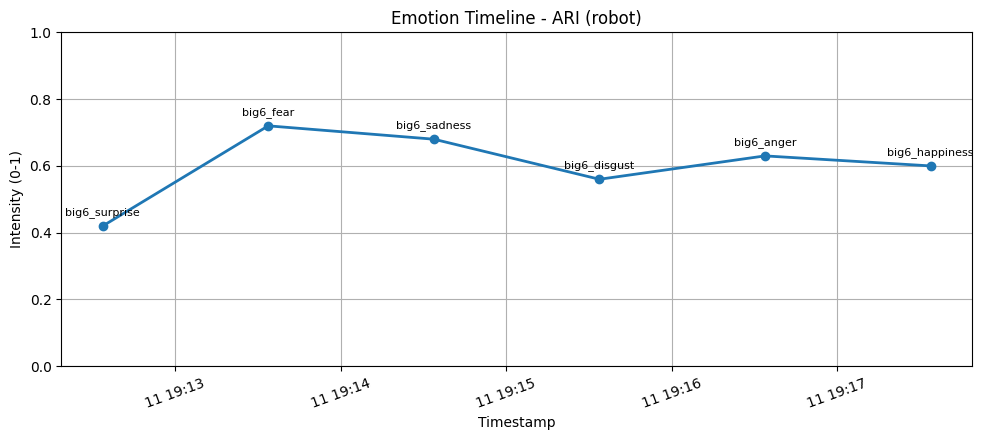

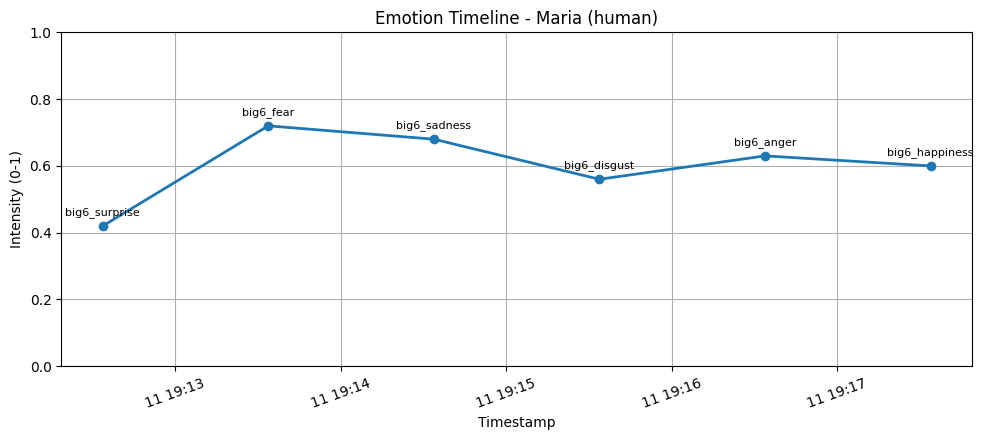

In [8]:
# Report 3: Temporal emotion analysis
q_emotion_time = '''
PREFIX onyx: <http://www.gsi.upm.es/ontologies/onyx/ns#>
PREFIX segb: <http://www.gsi.upm.es/ontologies/segb/ns#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX oa: <http://www.w3.org/ns/oa#>
PREFIX oro: <http://kb.openrobots.org#>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>

SELECT ?t ?sourceActivity ?targetEntity ?targetType ?targetLabel ?category ?intensity ?confidence
WHERE {
  ?sourceActivity a onyx:EmotionAnalysis ;
                 prov:startedAtTime ?t ;
                 segb:producedEntityResult ?annotation .
  ?annotation onyx:hasEmotion ?emotion ;
              oa:hasTarget ?targetEntity .
  ?emotion onyx:hasEmotionCategory ?category ;
           onyx:hasEmotionIntensity ?intensity .
  OPTIONAL { ?emotion onyx:algorithmConfidence ?confidence }

  OPTIONAL {
    ?targetEntity a oro:Robot .
    OPTIONAL { ?targetEntity oro:hasName ?robotName }
    BIND("robot" AS ?targetType)
    BIND(COALESCE(?robotName, STR(?targetEntity)) AS ?targetLabel)
  }
  OPTIONAL {
    ?targetEntity a prov:Person .
    OPTIONAL { ?targetEntity foaf:firstName ?personName }
    BIND("human" AS ?targetType)
    BIND(COALESCE(?personName, STR(?targetEntity)) AS ?targetLabel)
  }
  FILTER(BOUND(?targetType))
}
ORDER BY ?t DESC(?intensity)
'''

df_emotion_time = query_df(graph, q_emotion_time)
if not df_emotion_time.empty:
    df_emotion_time["intensity"] = pd.to_numeric(df_emotion_time["intensity"], errors="coerce")
    if "confidence" in df_emotion_time.columns:
        df_emotion_time["confidence"] = pd.to_numeric(df_emotion_time["confidence"], errors="coerce")
    df_emotion_time["t_human"] = df_emotion_time["t"].map(format_human_timestamp)

show_report_table(
    "Report 3 - Temporal Emotion Analysis",
    df_emotion_time,
    rename={
        "t_human": "Timestamp",
        "targetType": "Subject Type",
        "targetLabel": "Subject",
        "sourceActivity": "Emotion Analysis Activity",
        "category": "Emotion",
        "intensity": "Intensity",
        "confidence": "Confidence",
    },
    compact_columns=["sourceActivity", "category"],
)

plot_emotion_timeline(df_emotion_time)


In [9]:
# Report 4: Extreme emotions (threshold >= 0.75)
q_emotion_extreme = '''
PREFIX onyx: <http://www.gsi.upm.es/ontologies/onyx/ns#>
PREFIX segb: <http://www.gsi.upm.es/ontologies/segb/ns#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX oa: <http://www.w3.org/ns/oa#>
PREFIX oro: <http://kb.openrobots.org#>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?t ?sourceActivity ?targetEntity ?targetType ?targetLabel ?category ?intensity ?confidence
WHERE {
  ?sourceActivity a onyx:EmotionAnalysis ;
                 prov:startedAtTime ?t ;
                 segb:producedEntityResult ?annotation .
  ?annotation onyx:hasEmotion ?emotion ;
              oa:hasTarget ?targetEntity .
  ?emotion onyx:hasEmotionCategory ?category ;
           onyx:hasEmotionIntensity ?intensity .
  OPTIONAL { ?emotion onyx:algorithmConfidence ?confidence }

  OPTIONAL {
    ?targetEntity a oro:Robot .
    OPTIONAL { ?targetEntity oro:hasName ?robotName }
    BIND("robot" AS ?targetType)
    BIND(COALESCE(?robotName, STR(?targetEntity)) AS ?targetLabel)
  }
  OPTIONAL {
    ?targetEntity a prov:Person .
    OPTIONAL { ?targetEntity foaf:firstName ?personName }
    BIND("human" AS ?targetType)
    BIND(COALESCE(?personName, STR(?targetEntity)) AS ?targetLabel)
  }
  FILTER(BOUND(?targetType))
  FILTER (xsd:double(?intensity) >= 0.75)
}
ORDER BY DESC(?intensity)
'''

df_emotion_extreme = query_df(graph, q_emotion_extreme)
if not df_emotion_extreme.empty:
    df_emotion_extreme["intensity"] = pd.to_numeric(df_emotion_extreme["intensity"], errors="coerce")
    if "confidence" in df_emotion_extreme.columns:
        df_emotion_extreme["confidence"] = pd.to_numeric(df_emotion_extreme["confidence"], errors="coerce")
    df_emotion_extreme["t_human"] = df_emotion_extreme["t"].map(format_human_timestamp)

show_report_table(
    "Report 4 - Extreme Emotions",
    df_emotion_extreme,
    rename={
        "t_human": "Timestamp",
        "targetType": "Subject Type",
        "targetLabel": "Subject",
        "sourceActivity": "Emotion Analysis Activity",
        "category": "Emotion",
        "intensity": "Intensity",
        "confidence": "Confidence",
    },
    compact_columns=["sourceActivity", "category"],
)

plot_extreme_emotions(df_emotion_extreme)


### Report 4 - Extreme Emotions

_No data available for this report._

In [10]:
# Report 8: Movement/displacement report from robot states
q_state = '''
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX schema: <http://schema.org/>
PREFIX oro: <http://kb.openrobots.org#>

SELECT ?robot ?robotName ?t ?location
WHERE {
  ?state a prov:Entity ;
         prov:wasAttributedTo ?robot ;
         prov:generatedAtTime ?t ;
         schema:location ?location .
  OPTIONAL { ?robot oro:hasName ?robotName }
}
ORDER BY ?robot ?t
'''

df_state = query_df(graph, q_state)
if not df_state.empty:
    df_state["t"] = pd.to_datetime(df_state["t"], utc=True)
    df_state["t_human"] = df_state["t"].map(format_human_timestamp)

show_report_table(
    "Report 8 - State Timeline",
    df_state,
    rename={
        "robot": "Robot URI",
        "robotName": "Robot",
        "t_human": "Timestamp",
        "location": "Location URI",
    },
    compact_columns=["robot", "location"],
)

if not df_state.empty:
    summary_rows = []
    for robot, group in df_state.sort_values("t").groupby("robot"):
        locations = list(group["location"])
        changes = sum(1 for i in range(1, len(locations)) if locations[i] != locations[i - 1])
        summary_rows.append(
            {
                "robot": compact_uri(robot),
                "samples": len(locations),
                "location_changes": changes,
                "path": " -> ".join(compact_uri(x) for x in locations),
            }
        )
    df_summary = pd.DataFrame(summary_rows)
    show_report_table(
        "Report 8 - Derived Displacement Summary",
        df_summary,
        rename={
            "robot": "Robot",
            "samples": "State Samples",
            "location_changes": "Location Changes",
            "path": "Observed Path",
        },
    )


### Report 8 - State Timeline

,Robot URI,Robot,t,Location URI,Timestamp
0,ari1,ARI,2026-02-11 19:12:33.794600+00:00,room_a,11 feb 2026 19:12:33 UTC
1,ari1,ARI,2026-02-11 19:14:33.794600+00:00,room_b,11 feb 2026 19:14:33 UTC
2,tiago1,TIAGo,2026-02-11 19:12:33.794600+00:00,room_b,11 feb 2026 19:12:33 UTC
3,tiago1,TIAGo,2026-02-11 19:15:33.794600+00:00,room_c,11 feb 2026 19:15:33 UTC


### Report 8 - Derived Displacement Summary

,Robot,State Samples,Location Changes,Observed Path
0,ari1,2,1,room_a -> room_b
1,tiago1,2,1,room_b -> room_c


## Notes

- This notebook does not modify the production library.
- It only composes existing APIs and adds RDF triples in-memory for demonstration purposes.
- For production reports, keep queries versioned and run them against the central KG.


In [ ]:
# Bonus: KG visual snapshot (report-oriented)
display(Markdown("## KG Visual Snapshot"))

try:
    import networkx as nx
except Exception:
    display(Markdown("_Install `networkx` to enable graph visualization: `pip install networkx`._"))
else:
    focus_predicates = {
        SEGB.triggeredByActivity,
        SEGB.triggeredByEntity,
        SEGB.producedEntityResult,
        SEGB.wasPerformedBy,
        PROV.wasGeneratedBy,
        PROV.specializationOf,
        OA.hasTarget,
    }

    max_edges = 120
    selected_edges = []
    for s, p, o in graph:
        if p not in focus_predicates:
            continue
        selected_edges.append((s, p, o))
        if len(selected_edges) >= max_edges:
            break

    if not selected_edges:
        display(Markdown("_No edges found for the selected semantic predicates._"))
    else:
        kg = nx.MultiDiGraph()

        def node_group(uri_text: str) -> str:
            if "/robots/ari/" in uri_text:
                return "ari"
            if "/robots/tiago/" in uri_text:
                return "tiago"
            if "/shared-events/" in uri_text:
                return "shared"
            if "/human/" in uri_text:
                return "human"
            return "other"

        palette = {
            "ari": "#4C78A8",
            "tiago": "#F58518",
            "shared": "#54A24B",
            "human": "#E45756",
            "other": "#9D9D9D",
        }

        edge_labels = {}
        for s, p, o in selected_edges:
            s_text = str(s)
            o_text = str(o)
            p_text = compact_uri(p)
            kg.add_node(s_text, label=compact_uri(s), group=node_group(s_text))
            kg.add_node(o_text, label=compact_uri(o), group=node_group(o_text))
            kg.add_edge(s_text, o_text, label=p_text)
            edge_labels[(s_text, o_text)] = p_text

        pos = nx.spring_layout(kg, seed=42, k=1.1)
        node_colors = [palette.get(kg.nodes[n].get("group", "other"), "#9D9D9D") for n in kg.nodes]
        node_labels = {n: kg.nodes[n]["label"] for n in kg.nodes}

        fig, ax = plt.subplots(figsize=(14, 10))
        nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=900, alpha=0.9, ax=ax)
        nx.draw_networkx_edges(
            kg,
            pos,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=14,
            edge_color="#666666",
            width=1.2,
            alpha=0.7,
            ax=ax,
        )
        nx.draw_networkx_labels(kg, pos, labels=node_labels, font_size=8, font_color="black", ax=ax)

        # Show a subset of edge labels to keep the chart readable.
        edge_labels_subset = dict(list(edge_labels.items())[:50])
        nx.draw_networkx_edge_labels(kg, pos, edge_labels=edge_labels_subset, font_size=7, ax=ax)

        truncated_note = ""
        if len(selected_edges) >= max_edges:
            truncated_note = f" (showing first {max_edges} edges)"

        ax.set_title(f"SEGB Knowledge Graph Snapshot{truncated_note}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
